In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("swiggy_all_menus_india.csv")

In [3]:
df.head()

,State,City,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,0.0,0


In [4]:
df.shape

(197430, 9)

In [5]:
df.columns

Index(['State', 'City', 'Restaurant Name', 'Location', 'Category', 'Dish Name',
       'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [6]:
df.rename(columns={'Price (INR)':'Price'}, inplace=True)

#### Renaming columns to snake_case (column normalization)

In [7]:
df.columns=df.columns.str.strip().str.replace(" ","_")

In [8]:
df.columns

Index(['State', 'City', 'Restaurant_Name', 'Location', 'Category', 'Dish_Name',
       'Price', 'Rating', 'Rating_Count'],
      dtype='object')

### 1. Clean the Dataset

- Handle missing values (fill or drop as required).
- Remove or treat outliers.
- Drop irrelevant or unwanted columns.
- Ensure the dataset is consistent and ready for analysis

#### Handle missing values (fill or drop as required).

In [9]:
df.isna().sum()

State              0
City               0
Restaurant_Name    0
Location           0
Category           0
Dish_Name          0
Price              0
Rating             0
Rating_Count       0
dtype: int64

#### For this dataset there is no missing values here. So no need to handle missing values.

#### Handling duplicated values

In [10]:
df.duplicated().sum()

np.int64(6104)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

### Remove or treat outliers

<Axes: >

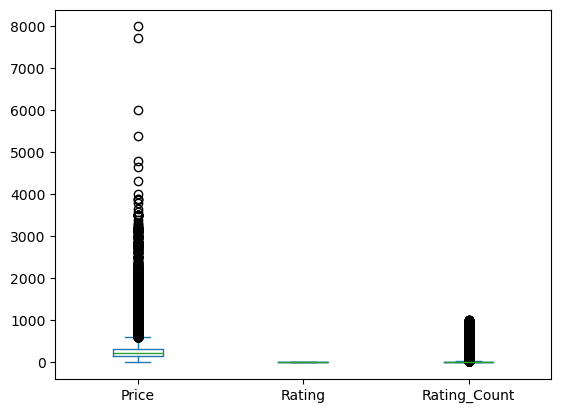

In [13]:
df.plot(kind="box")

In [14]:
Q1,Q2,Q3 = np.percentile(df["Price"],[25,50,75])
Q1,Q2,Q3

(np.float64(139.0), np.float64(229.0), np.float64(329.0))

In [15]:
IQR = Q3-Q1
lower_whisker = Q1-1.5*IQR
upper_whisker = Q3+1.5*IQR
outliers_of_price = df[(df["Price"]<lower_whisker) | (df["Price"]>upper_whisker)]
outliers_of_price

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
563,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Recommended,Bold BBQ Veggie Thin n Crispy,749.00,4.6,7
592,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Bold BBQ Veggie Thin n Crispy,749.00,4.6,7
593,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Tandoori Paneer Thin n Crispy,749.00,5.0,6
594,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Mexican Fiesta Thin n Crispy,749.00,3.8,1
595,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Dhabe Da Keema Thin n Crispy,749.00,0.0,0
...,...,...,...,...,...,...,...,...,...
197116,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Ultimate Cheese Burst Deluxe Combo (N Veg),815.00,0.0,0
197117,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Ultimate Cheese Burst Premium Combo (Veg),931.00,0.0,0
197118,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Meal for 4: Veg Cheesy Pizza,891.00,0.0,0
197120,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Meal for 2: Veg Paradise & Farmhouse,667.14,0.0,0


In [16]:
# Percentage of outlier in Price column

(len(outliers_of_price)/len(df))*100

4.9737097937551615

#### The Price column in this dataset has 5% of outilers, now we'll treat these outlier by using capping.

In [17]:
def capping_price(x):
    if x<lower_whisker:
        x=lower_whisker
    elif x>upper_whisker:
        x=upper_whisker
    else:
        return x
    return x  

In [18]:
df["Price"]=df["Price"].apply(capping_price)

<Axes: >

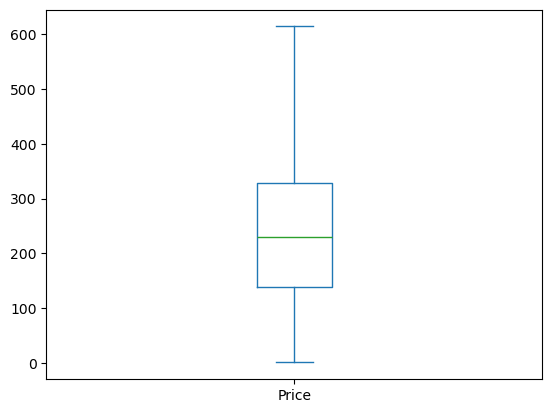

In [19]:
 df["Price"].plot(kind="box")

In [20]:
Q1,Q2,Q3=np.percentile(df['Rating_Count'],[25,50,75])
Q1,Q2,Q3

(np.float64(0.0), np.float64(2.0), np.float64(15.0))

In [21]:
 IQR=Q3-Q1
 lower_whisker=Q1-1.5*IQR
 upper_whisker=Q3+1.5*IQR
 outliers_of_rating=df[(df['Rating_Count']<lower_whisker) | (df['Rating_Count']>upper_whisker)]
 outliers_of_rating

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.00,4.7,48
3,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.00,4.6,65
9,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.00,4.9,51
38,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Fry,182.00,4.3,68
61,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Manchurian & Chilly,Mushroom Pepper Dry,228.00,2.6,45
...,...,...,...,...,...,...,...,...,...
196213,Sikkim,Gangtok,KFC,Baluwakhani,BURGERS,Chicken Zinger Burger - Classic,234.13,4.5,40
197314,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Recommended,Veg roll,70.00,4.3,59
197320,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Recommended,Veg chowmein ...,70.00,4.1,46
197360,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Roll,Veg roll,70.00,4.3,59


In [22]:
(len(outliers_of_rating)/len(df))*100

14.748648902919623

#### “The Rating Count column in this dataset contains 14% outliers. Treat these outliers by applying capping.”

In [23]:
def capping_rating(x):
    if x<lower_whisker:
        x=lower_whisker
    elif x>upper_whisker:
        x=upper_whisker
    else:
        return x
    return x 

In [24]:
 df['Rating_Count']=df['Rating_Count'].apply(capping_rating)

<Axes: >

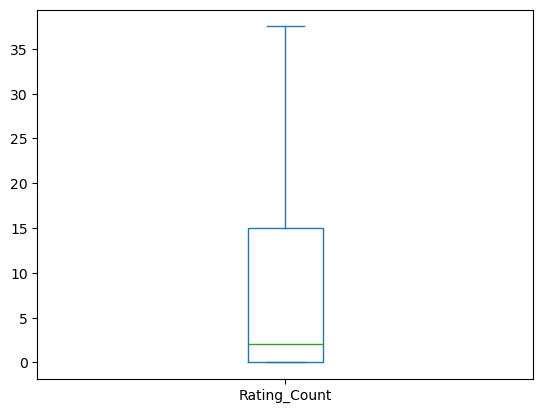

In [25]:
 df['Rating_Count'].plot(kind="box")

####  Drop irrelevant or unwanted columns.

In [26]:
df.head(1)

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0.0


#### “All columns in this dataset are required for analysis to address business-driven decision questions.”

#### "Ensure the dataset is consistent and ready for analysis"

#### "Check by using some key parameters"

In [27]:
df.isna().sum()

State              0
City               0
Restaurant_Name    0
Location           0
Category           0
Dish_Name          0
Price              0
Rating             0
Rating_Count       0
dtype: int64

In [28]:
df.dtypes

State               object
City                object
Restaurant_Name     object
Location            object
Category            object
Dish_Name           object
Price              float64
Rating             float64
Rating_Count       float64
dtype: object

In [29]:
df.duplicated().sum()

np.int64(71)

In [30]:
# ensure values are falls within expected range
max_rating=df["Rating"].max()
min_rating=df["Rating"].min()
print(max_rating)
print(min_rating)

5.0
0.0


<Axes: >

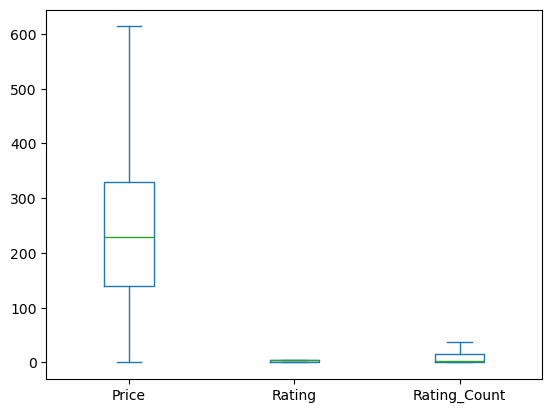

In [31]:
# outlier checking 
df.plot(kind="box")

In [32]:
# formatting columns
df.columns

Index(['State', 'City', 'Restaurant_Name', 'Location', 'Category', 'Dish_Name',
       'Price', 'Rating', 'Rating_Count'],
      dtype='object')

In [33]:
# integrity check (min_price<= max_price)
min_price=df["Price"].min()
max_price=df["Price"].max()
print(min_price)
print(max_price)

0.95
614.0


#### After performing data cleaning and preprocessing, the dataset has been ensured to be complete, consistent, and reliable. All missing values and duplicates have been handled, data types have been correctly assigned, outliers in numeric columns have been addressed, categorical values have been standardized, and irrelevant columns have been removed. The dataset is now clean, structured, and ready for analysis or modeling.

#### Explore the dataset:

####  Go through each column carefully to understand its data type,meaning and summarize the dataset.

In [34]:
df.dtypes

State               object
City                object
Restaurant_Name     object
Location            object
Category            object
Dish_Name           object
Price              float64
Rating             float64
Rating_Count       float64
dtype: object

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191326 entries, 0 to 197429
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            191326 non-null  object 
 1   City             191326 non-null  object 
 2   Restaurant_Name  191326 non-null  object 
 3   Location         191326 non-null  object 
 4   Category         191326 non-null  object 
 5   Dish_Name        191326 non-null  object 
 6   Price            191326 non-null  float64
 7   Rating           191326 non-null  float64
 8   Rating_Count     191326 non-null  float64
dtypes: float64(3), object(6)
memory usage: 14.6+ MB


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,191326.0,252.072443,146.395450,0.95,139.0,229.0,329.0,614.0
Rating,191326.0,2.607342,2.146412,0.00,0.0,3.9,4.5,5.0
Rating_Count,191326.0,9.842097,13.752102,0.00,0.0,2.0,15.0,37.5


In [37]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,191326,28,Karnataka,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,191326,28,Bengaluru,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_Name,191326,993,McDonald's,12833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,191326,977,Gomti Nagar,2054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,191326,4972,Recommended,23243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dish_Name,191326,59064,Choco Lava Cake,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,191326.0,NaN,NaN,NaN,252.072443,146.39545,0.95,139.0,229.0,329.0,614.0
Rating,191326.0,NaN,NaN,NaN,2.607342,2.146412,0.0,0.0,3.9,4.5,5.0
Rating_Count,191326.0,NaN,NaN,NaN,9.842097,13.752102,0.0,0.0,2.0,15.0,37.5


In [38]:
df["State"].value_counts()

State
Karnataka            18349
Maharashtra          10467
Telangana            10279
Delhi                10183
Tamil Nadu           10042
Rajasthan             9801
Uttar Pradesh         9581
West Bengal           9381
Punjab                9358
Gujarat               8867
Madhya Pradesh        7114
Meghalaya             5183
Jharkhand             5100
Uttarakhand           5084
Himachal Pradesh      5054
Assam                 5032
Goa                   5030
Kerala                5029
Chhattisgarh          5025
Odisha                5018
Haryana               5005
Manipur               5001
Bihar                 5000
Jammu and Kashmir     4974
Tripura               4947
Mizoram               3031
Nagaland              2286
Sikkim                2105
Name: count, dtype: int64

Text(0.5, 1.0, 'distribution of order in swiggy')

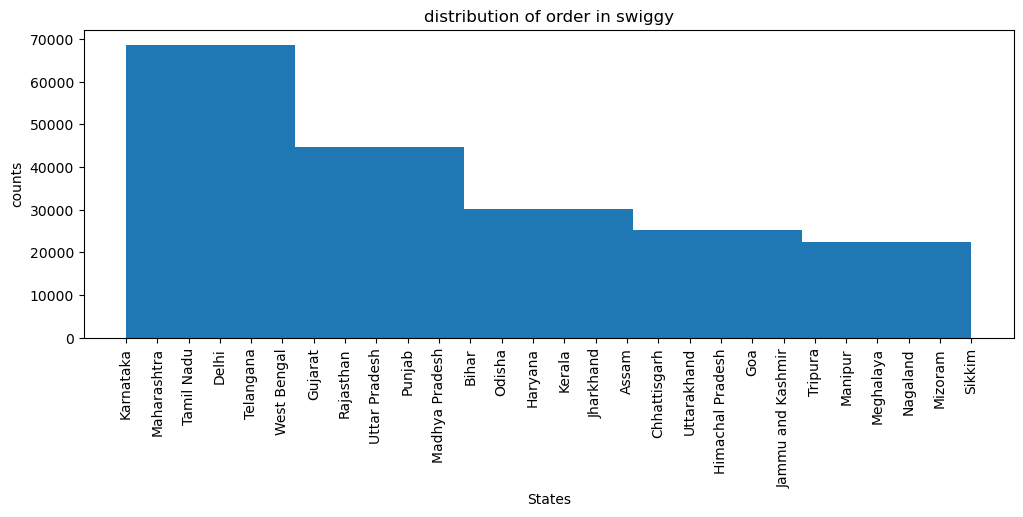

In [39]:
plt.figure(figsize=(12,4))
plt.hist(df["State"],bins=5)
plt.xticks(rotation=90)
plt.xlabel("States")
plt.ylabel("counts")
plt.title("distribution of order in swiggy")

In [40]:
df['City'].value_counts()

City
Bengaluru      18349
Mumbai         10467
Hyderabad      10279
New Delhi      10183
Chennai        10042
Jaipur          9801
Lucknow         9581
Kolkata         9381
Chandigarh      9358
Ahmedabad       8867
Indore          7114
Shillong        5183
Ranchi          5100
Dehradun        5084
Shimla          5054
Guwahati        5032
Panaji          5030
Kochi           5029
Raipur          5025
Bhubaneswar     5018
Gurgaon         5005
Imphal          5001
Patna           5000
Srinagar        4974
Agartala        4947
Aizawl          3031
Kohima          2286
Gangtok         2105
Name: count, dtype: int64

In [41]:
df["Location"].value_counts()

Location
Gomti Nagar            2054
Nerul                  2034
Yelahanka              1990
Police Bazar           1814
Vasant Kunj            1789
                       ... 
Mal Godown Market         4
SECTOR-109                3
Bohri Kadal               3
ASHIYANA DIGHA ROAD       3
Faridabad                 2
Name: count, Length: 977, dtype: int64

In [42]:
df["Category"].value_counts()

Category
Recommended                    23243
Main Course                     2953
Desserts                        2844
Beverages                       2405
McSaver Combos (2 Pc Meals)     1729
                               ...  
EID special sweet box              1
Combo Offer                        1
Food Pack Dinner                   1
Chinese- Dragon's Belly            1
make your own combo                1
Name: count, Length: 4972, dtype: int64

In [43]:
# how many categories place minimum order 
df1=pd.DataFrame(df["Category"].value_counts())

In [44]:
df1.reset_index(inplace=True)

In [45]:
series1=df1[df1["count"]==1]["Category"]

In [46]:
l1=list(series1)

In [47]:
len(l1)

336

In [48]:
df["Dish_Name"].unique()

array(['Butter Murukku-200gm', 'Badam Milk', 'Chow Chow Bath', ...,
       'Chilli cheese momo ', 'Veg Momos (8 Pc)', 'Soya Momo'],
      dtype=object)

In [49]:
df["Dish_Name"].value_counts()

Dish_Name
Choco Lava Cake                                       291
Veg Fried Rice                                        240
Paneer Butter Masala                                  225
Chicken Sausage                                       224
Jeera Rice                                            214
                                                     ... 
Sweet corn soup                                         1
Mushroom soup                                           1
Garlic soup                                             1
Crispy baby corn chilli                                 1
Puri aloo dum                                           1
Name: count, Length: 59064, dtype: int64

In [50]:
 df["Dish_Name"].value_counts()

Dish_Name
Choco Lava Cake                                       291
Veg Fried Rice                                        240
Paneer Butter Masala                                  225
Chicken Sausage                                       224
Jeera Rice                                            214
                                                     ... 
Sweet corn soup                                         1
Mushroom soup                                           1
Garlic soup                                             1
Crispy baby corn chilli                                 1
Puri aloo dum                                           1
Name: count, Length: 59064, dtype: int64

In [51]:
df

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0.0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25.0
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,37.5
3,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,37.5
4,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
197425,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,0.0,0.0
197426,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,0.0,0.0
197427,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,0.0,0.0
197428,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,0.0,0.0


In [52]:
# finding the relation between the numerical columns

numerical_col=df.select_dtypes(include="number").columns
numerical_col

Index(['Price', 'Rating', 'Rating_Count'], dtype='object')

In [53]:
df[numerical_col].corr()

,Price,Rating,Rating_Count
Price,1.000000,-0.107418,-0.155330
Rating,-0.107418,1.000000,0.576857
Rating_Count,-0.155330,0.576857,1.000000


In [54]:
df["State"].value_counts()

State
Karnataka            18349
Maharashtra          10467
Telangana            10279
Delhi                10183
Tamil Nadu           10042
Rajasthan             9801
Uttar Pradesh         9581
West Bengal           9381
Punjab                9358
Gujarat               8867
Madhya Pradesh        7114
Meghalaya             5183
Jharkhand             5100
Uttarakhand           5084
Himachal Pradesh      5054
Assam                 5032
Goa                   5030
Kerala                5029
Chhattisgarh          5025
Odisha                5018
Haryana               5005
Manipur               5001
Bihar                 5000
Jammu and Kashmir     4974
Tripura               4947
Mizoram               3031
Nagaland              2286
Sikkim                2105
Name: count, dtype: int64

In [55]:
df.Price.min()

0.95

In [56]:
df.Price.max()

614.0

In [57]:
df[df["Price"]==0.95]

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
636,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Appetizer,Tomato Ketchup,0.95,4.3,37.5
2410,Karnataka,Bengaluru,Pizza Hut,Global Mall,Appetizer,Tomato Ketchup,0.95,4.5,37.5
3900,Karnataka,Bengaluru,Pizza Hut,Banashankari,Appetizer,Tomato Ketchup,0.95,4.3,37.5
4409,Karnataka,Bengaluru,Pizza Hut,Varthur Gunjur,Appetizer,Tomato Ketchup,0.95,4.3,37.5
6267,Karnataka,Bengaluru,Pizza Hut,Jalahalli Cross,Appetizer,Tomato Ketchup,0.95,4.2,37.5
...,...,...,...,...,...,...,...,...,...
188262,Meghalaya,Shillong,Pizza Hut,Police Bazaar,Appetizer,Tomato Ketchup,0.95,4.2,37.5
192441,Mizoram,Aizawl,Pizza Hut,Aizwal,Appetizer,Tomato Ketchup,0.95,4.5,30.0
194306,Mizoram,Aizawl,Pizza Hut,Bawngkawn,Appetizer,Tomato Ketchup,0.95,3.8,26.0
194871,Mizoram,Aizawl,Pizza Hut,Aizawl,Appetizer,Tomato Ketchup,0.95,4.2,22.0


In [58]:
df[df["Price"]==614.0]

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
563,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Recommended,Bold BBQ Veggie Thin n Crispy,614.0,4.6,7.0
592,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Bold BBQ Veggie Thin n Crispy,614.0,4.6,7.0
593,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Tandoori Paneer Thin n Crispy,614.0,5.0,6.0
594,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Mexican Fiesta Thin n Crispy,614.0,3.8,1.0
595,Karnataka,Bengaluru,Pizza Hut,Kanakapura Road,Thin n Crispy Pizzas,Dhabe Da Keema Thin n Crispy,614.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
197116,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Ultimate Cheese Burst Deluxe Combo (N Veg),614.0,0.0,0.0
197117,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Ultimate Cheese Burst Premium Combo (Veg),614.0,0.0,0.0
197118,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Meal for 4: Veg Cheesy Pizza,614.0,0.0,0.0
197120,Sikkim,Gangtok,Domino's Pizza,DISTRICT COURT,Value Meals,Meal for 2: Veg Paradise & Farmhouse,614.0,0.0,0.0


In [59]:
df.Rating.value_counts()

Rating
0.0    75490
4.3    11299
4.6    10517
4.4    10431
4.5     9627
5.0     9060
4.7     8781
4.8     8502
4.2     7922
4.1     6909
4.9     5528
4.0     4846
3.9     3883
3.8     3850
3.7     2627
3.6     1960
3.5     1825
3.4     1301
3.3     1243
3.2      972
3.0      726
3.1      675
2.8      538
2.9      530
2.7      422
2.6      300
2.5      281
2.0      244
2.4      229
2.3      223
2.2      207
2.1      159
1.5       64
1.8       53
1.9       48
1.6       30
1.7       24
Name: count, dtype: int64

#### Document understanding of what each column represents

#### Document

#### States Column:

- The state column represent in which the state order is placed in india.
- I obsereved ,karnataka state got more order among all the states in india .the lowest
 orders place in sikkim state.
- The telangana,delhi,tamilnaidu relatively similar order placed.and these states got
 more than 70% orders of karantaka
- Level of states got order
  - low orders: Mizoram,Nagaland,Sikkim
  - medium orders: Meghalaya,Jharkhand,Uttarakhand,Himachal
    Pradesh,Assam,Goa,Kerala,Chhattisgarh,Odisha,Haryana,Manipur Bihar,Jammu
    and Kashmir .
  - high orders: Maharashtra ,Telangana,Delhi,Tamil Nadu,Rajasthan,Uttar Pradesh
   ,West Bengal,Punjab

#### Cities Column:

- The cities column also represents in which city order on the state.
- The states parllel cities got orders.in this data cities are capital cities of the state.

#### Location Column:

* The location column represents where the restaurant received orders.
* Gomti Nagar had the highest number of orders.
* Faridabad had the lowest number of orders among all locations.
* Many high-order locations are situated in Karnataka.



#### Category column:

* The category column represents the category of the dish ordered.
* The “Recommended” category received more orders compared to other categories.
* The least-ordered categories include 336 categories that received only one order each.



#### dish_name column:

* The dish_name column represents which dish the customer ordered.
* There are nearly 59,064 dish entries in this dataset.
* Choco Lava Cake received the highest number of orders.
* The top 5 most-ordered dishes are Choco Lava Cake, Veg Fried Rice, Paneer Butter Masala, Chicken Sausage, and Jeera Juice.



#### Price column:

* The price column represents the price of each dish.
* After outlier capping, item prices range from ₹0.95 to ₹614.
* The lowest-priced item is Tomato Ketchup.
* The highest-priced item is Bold BBQ Veggie Thin n Crispy (and similar items).



#### Rating column:

* The rating column represents the rating given by the customer to the dish.
* Ratings range from 0 to 5.
* Most dishes received a rating of 4.3, except for those rated 0.0.



#### **3. Generate Questions & Answers**

Based on exploration, created at least **10 meaningful questions** and answer those questions using **Pandas functions**.

#### **Questions**

* Which state is getting the most orders?
* Which state is getting the fewest orders?
* What percentage of total orders is contributed by Karnataka?
* What are the top 3 states with the highest number of orders?
* Which top 10 locations receive the most orders?
* Which category received the most orders?
* Which category received the fewest orders?
* What are the top 5 categories that received the highest number of orders?
* Which dish received the most orders?
* What are the top 5 most-ordered dishes?
* Which dish category is ordered the most?
* Please give the top 3 most-rated items (based on rating).
* Please provide the number of ratings given to each dish and location.


In [60]:
# which state getting more orders?

df.State.value_counts().idxmax()

'Karnataka'

#### Insight : Karnataka got more orders

In [61]:
# which state getting more orders?

df.State.value_counts().idxmin()

'Sikkim'

#### Insight : Sikkim got less orders

In [62]:
# what percentage of orders covered by karantaka?

total_orders=len(df)
karantaka_count=len(df[df['State']=='Karnataka'])
percent_karantaka=(karantaka_count/total_orders)*100
percent_karantaka

9.590437264146011

#### Insight : Around 9.5 percentage order from karantaka on overall

In [63]:
# top 3 states  got order more?
df.State.value_counts().sort_values(ascending=False).head(3)

State
Karnataka      18349
Maharashtra    10467
Telangana      10279
Name: count, dtype: int64

#### Insight : The order get ranking is 1.Karnataka 18349 2.Maharashtra 10467 3.Telangana 10279

In [64]:
# top 10 location give more orders?
df.Location.value_counts().sort_values(ascending=False).head(10)

Location
Gomti Nagar      2054
Nerul            2034
Yelahanka        1990
Police Bazar     1814
Vasant Kunj      1789
Whitefield       1727
Thane West       1711
Jagatpura        1662
Gangtok          1544
Shankar Nagar    1460
Name: count, dtype: int64

#### Insight : These are top 10 order getting locations Gomti Nagar,Nerul,Yelahanka,Police Bazar,Vasant Kunj,Whitefield ,Thane West,Jagatpura,Gangtok ,Shankar Nagar 1460.

In [65]:
# which category got more orders?
df.Category.value_counts().sort_values(ascending=False).idxmax()

'Recommended'

#### The recommended category got more orders

In [66]:
# which category got low orders?
df.Category.value_counts().sort_values(ascending=False).idxmin()

'RAKSHA BANDHAN SPECIAL'

#### RAKSHA BANDHAN SPECIAL category got minimum order with only one order

In [67]:
# top 5 category give more orders?

df.Category.value_counts().sort_values(ascending=False).iloc[:5]

Category
Recommended                    23243
Main Course                     2953
Desserts                        2844
Beverages                       2405
McSaver Combos (2 Pc Meals)     1729
Name: count, dtype: int64

In [68]:
df.head(2)

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0.0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25.0


In [69]:
# give name of the dish get more orders?
df.Dish_Name.value_counts().sort_values(ascending=False).idxmax()

'Choco Lava Cake'

#### Choco Lava Cake more ordered item

In [70]:
# - what are top 5 dishes ordered more?
df.Dish_Name.value_counts().sort_values(ascending=False).iloc[:5]

Dish_Name
Choco Lava Cake         291
Veg Fried Rice          240
Paneer Butter Masala    225
Chicken Sausage         224
Jeera Rice              214
Name: count, dtype: int64

#### These are the top 5 dishes 1.Choco Lava Cake 2.Veg Fried Rice 3.Paneer Butter Masala 4.Chicken Sausage 5.Jeera Rice

In [71]:
# what are the average orders of  dishes?
df.groupby("Dish_Name")["Price"].mean().sort_values(ascending=False)

Dish_Name
Chicken Extravaganza Pizza and Garlic Knots Combo    614.000000
Chicken Full Smash Pizza [BIG 10"]                   614.000000
Chicken Dum Biryani Combo                            614.000000
 House Party wali   Meal-Non-veg                     614.000000
 Kosha Mangsho                                       614.000000
                                                        ...    
Ketchup Sacthe                                         1.500000
Tomato Ketchup                                         1.155114
Tomato Ketchup Sachet                                  1.000000
DIY Fresh Foodie Bag                                   1.000000
Ketchup                                                0.952174
Name: Price, Length: 59064, dtype: float64

In [72]:
# which category of dishes ordered most?
df.groupby(by="Category")["Dish_Name"].count().idxmax()

'Recommended'

In [73]:
# what are those dishes
df[df.Category=="Recommended"]["Dish_Name"]

1                                                Badam Milk
2                                            Chow Chow Bath
3                                               Kesari Bath
4                                                Mix Raitha
5                                    Srinidhi Sagar Special
                                ...                        
197320    Veg chowmein                                  ...
197321                                        Soya chowmein
197322                                      Paneer chowmein
197323    Veg thukpa                                    ...
197324                                         Mix chowmien
Name: Dish_Name, Length: 23243, dtype: object

In [74]:
# count of those dishes
len(df[df.Category=="Recommended"]["Dish_Name"])

23243

In [75]:
# please give more number of rating  get dish and location?
df[["Dish_Name","Rating"]].sort_values(by="Rating",ascending=False).head(3)

,Dish_Name,Rating
165729,Schweppes Water bottle,5.0
165719,Ice Americano Coffee,5.0
165709,Korean Spice Mix,5.0


In [76]:
df.head(3)

,State,City,Restaurant_Name,Location,Category,Dish_Name,Price,Rating,Rating_Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0.0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25.0
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,37.5


In [77]:
# give one more number of rating get dish and location?

df[["Dish_Name","Location","Rating_Count"]].sort_values(by="Rating_Count").max()

Dish_Name       |OB Chicken Tikka
Location                yelahanka
Rating_Count                 37.5
dtype: object

#### The more rating_count dish_name is OB Chicken Tikka,location is yelahanka ,rating_count with 37.5

#### 4. Perform Analysis:

In [78]:
# checking correlation between numerical columns in the dataset
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols

Index(['Price', 'Rating', 'Rating_Count'], dtype='object')

In [79]:
 df[numerical_cols].corr()

,Price,Rating,Rating_Count
Price,1.000000,-0.107418,-0.155330
Rating,-0.107418,1.000000,0.576857
Rating_Count,-0.155330,0.576857,1.000000


#### There is no correlation between price to rating and price to rating_count .But there is a weak postive correlation on rating and Rating_Count

####  5. Summary & Insights: Write a short summary of your analysis.

### Key Insights from Swiggy Dataset Analysis


##### **1. State-level Orders**

* Karnataka has the highest number of orders.
* Sikkim has the lowest.
* A few states—Karnataka, Maharashtra, Telangana, Delhi, and Tamil Nadu—dominate overall orders, indicating a high concentration in metro regions.


##### **2. City-level Trends**

* Bengaluru tops the list in city-level orders.
* Most orders are concentrated in capital or major metropolitan cities.


##### **3. Location Insights**

* Gomti Nagar (Lucknow) has the highest number of orders among all individual locations.
* Some locations, such as Faridabad, receive very few orders.


##### **4. Category Analysis**

* The **“Recommended”** category receives the highest number of orders.
* Many niche categories have extremely low order counts, with more than 300 categories having only a single order.


##### **5. Dish Preferences**

* The most ordered dish is **Choco Lava Cake**.
* Other top dishes include **Veg Fried Rice, Paneer Butter Masala, Chicken Sausage, and Jeera Rice**.


##### **6. Price Distribution**

* Dish prices range from **₹0.95** (e.g., Tomato Ketchup) to **₹614** (premium pizzas/meals).
* The average dish price is approximately **₹252**.


##### **7. Ratings**

* Ratings range from **0 to 5**.
* A large number of dishes have a rating of **0**, indicating they were not rated.
* Common positive ratings include **4.3, 4.5, and 4.6**.


##### **8. Correlation Insights**

* **Price vs Rating:** Shows a weak negative correlation (higher-priced dishes do not necessarily receive higher ratings).
* **Price vs Rating Count:** Weak negative correlation.
* **Rating vs Rating Count:** Moderate positive correlation (popular dishes with more ratings tend to have higher ratings).


##### **9. Top-Rated Items**

Examples of dishes with a **5.0 rating** include:

* Schweppes Water Bottle
* Ice Americano Coffee
* Korean Spice Mix


##### **10. Most Reviewed Dish**

* **“OB Chicken Tikka”** at **Yelahanka** has the highest number of rating counts.



#### **Business Value**

* Focus promotions on top-performing states and cities (such as Karnataka and Bengaluru).
* Promote bestsellers like **Choco Lava Cake** across new markets.
* Optimize pricing strategies, as premium pricing does not directly improve ratings.
* Increase visibility of under-ordered categories and dishes to help balance demand.
